   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 13.6 MB/s eta 0:00:00
⚠️ WESAD file not found. Generating SYNTHETIC ECG for demonstration...
✅ Synthetic Data Generated.

[Step 2] Preprocessing ECG...
   -> Found 5401 R-peaks.

[Step 3] Extracting HRV Features using Sliding Windows...
   -> Extracted 349 windows.
   -> Class Distribution: Baseline=175, Stress=174

[Step 4] Training Machine Learning Models...

--- Logistic Regression ---
Accuracy: 1.0000
              precision    recall  f1-score   support

    Baseline       1.00      1.00      1.00        53
      Stress       1.00      1.00      1.00        52

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105


--- Random Forest ---
Accuracy: 1.0000
              precision    recall  f1-score   support

    Baseline       1.00      1.00      1.00        53
      Stress       1.00      1.00      1.00        52

 

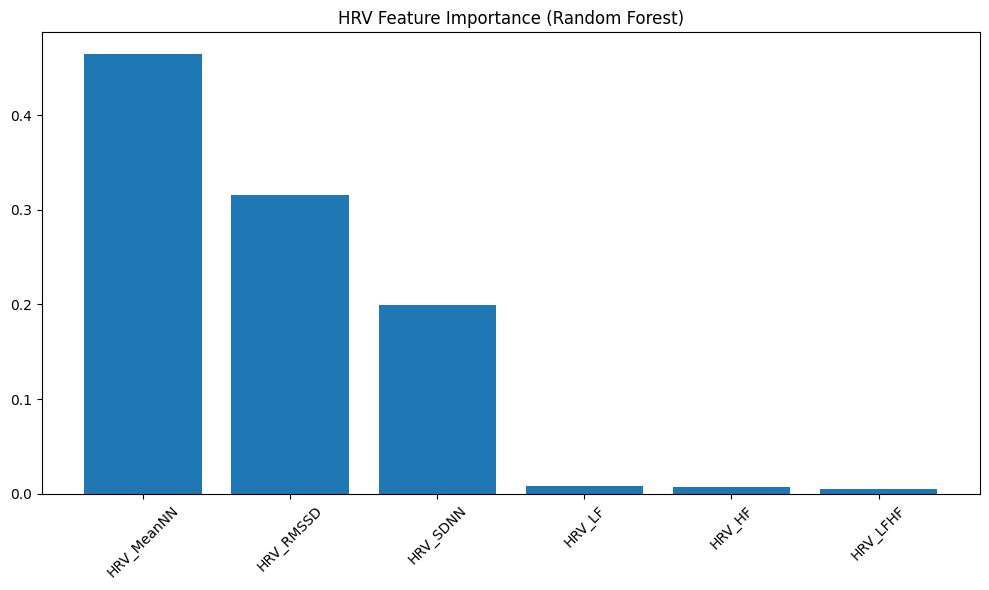


[Physiological Interpretation]
1. Stress typically leads to LOWER HRV (SDNN, RMSSD).
2. Stress typically increases LF power (sympathetic) and decreases HF power (parasympathetic).
3. Therefore, LF/HF ratio usually INCREASES during stress.


In [1]:
# ==========================================
# 1. SETUP & IMPORTS
# ==========================================
!pip install neurokit2 -q

import numpy as np
import pandas as pd
import pickle
import os
import neurokit2 as nk
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Configuration
# WESAD Chest ECG is 700 Hz
FS = 700
WINDOW_SIZE = 60  # Window size for HRV extraction (seconds)
WINDOW_STEP = 10  # Overlap step (seconds)
SUBJECT_FILE = 'S2.pkl'

# ==========================================
# 2. DATA LOADING (WESAD or SYNTHETIC)
# ==========================================
def load_wesad_s2(file_path):
    """Loads ECG and Labels from WESAD S2.pkl file."""
    print(f"Loading {file_path}...")
    with open(file_path, 'rb') as file:
        data = pickle.load(file, encoding='latin1')

    # Extract ECG (Chest) and Labels
    ecg = data['signal']['chest']['ECG'].flatten()
    labels = data['label'].flatten()

    return ecg, labels

def generate_synthetic_data(duration_sec=3600):
    """Generates synthetic ECG data mimicking WESAD structure if file is missing."""
    print("⚠️ WESAD file not found. Generating SYNTHETIC ECG for demonstration...")

    # Create two segments: Baseline (Rest) and Stress
    # Baseline: 70 bpm, high HRV | Stress: 110 bpm, low HRV + noise
    n_samples = duration_sec * FS
    half_samples = n_samples // 2

    # 1. Baseline Segment
    ecg_base = nk.ecg_simulate(duration=duration_sec//2, sampling_rate=FS,
                               heart_rate=70, random_state=42, noise=0.05)
    labels_base = np.ones(len(ecg_base)) # WESAD Label 1 = Baseline

    # 2. Stress Segment (higher HR, lower variability)
    ecg_stress = nk.ecg_simulate(duration=duration_sec//2, sampling_rate=FS,
                                 heart_rate=110, random_state=42, noise=0.2)
    labels_stress = np.full(len(ecg_stress), 2) # WESAD Label 2 = Stress

    # Combine
    ecg = np.concatenate([ecg_base, ecg_stress])
    labels = np.concatenate([labels_base, labels_stress])

    return ecg, labels

# Main Loader Logic
if os.path.exists(SUBJECT_FILE):
    ecg_signal, labels = load_wesad_s2(SUBJECT_FILE)
    print("✅ WESAD Data Loaded Successfully.")
else:
    ecg_signal, labels = generate_synthetic_data()
    print("✅ Synthetic Data Generated.")

# ==========================================
# 3. PREPROCESSING (Filter & Peak Detection)
# ==========================================
print("\n[Step 2] Preprocessing ECG...")

# 1. Clean ECG (NeuroKit2 uses a 0.5Hz highpass and powerline filtering by default)
# We can strictly enforce 0.5-40Hz bandpass as requested
ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=FS, method="neurokit")

# 2. Find Peaks
# We use 'prominence' method or 'neurokit' (adaptive thresholding)
signals, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=FS)
r_peaks = info["ECG_R_Peaks"]

print(f"   -> Found {len(r_peaks)} R-peaks.")

# ==========================================
# 4. FEATURE EXTRACTION (Windowing & HRV)
# ==========================================
print("\n[Step 3] Extracting HRV Features using Sliding Windows...")

features_list = []
target_labels = []

# Filter for only Baseline (1) and Stress (2)
valid_indices = np.where((labels == 1) | (labels == 2))[0]

# We need continuous segments to apply windowing.
# WESAD labels are usually continuous blocks.
# Strategy: Iterate through the signal, check if a window is fully within one label.

max_sample = len(ecg_signal)
step_samples = WINDOW_STEP * FS
window_samples = WINDOW_SIZE * FS

for start_idx in range(0, max_sample - window_samples, step_samples):
    end_idx = start_idx + window_samples

    # Check the labels in this window
    window_labels = labels[start_idx:end_idx]

    # Use mode to find dominant label
    # In strict mode: we only take windows that are 100% one class
    if np.all(window_labels == 1):
        current_label = 0 # Class 0 for Baseline
    elif np.all(window_labels == 2):
        current_label = 1 # Class 1 for Stress
    else:
        continue # Skip mixed windows (transitions)

    # Get peaks that fall within this window
    # We subtract start_idx to make peaks relative to the window start (crucial for freq analysis)
    peaks_in_window = r_peaks[(r_peaks >= start_idx) & (r_peaks < end_idx)]
    peaks_relative = peaks_in_window - start_idx

    if len(peaks_relative) < 10: # Skip if too few peaks (noise/artifact)
        continue

    # Compute HRV
    try:
        # Time Domain
        hrv_time = nk.hrv_time(peaks_relative, sampling_rate=FS, show=False)

        # Frequency Domain
        # Welch's method is robust for short windows
        hrv_freq = nk.hrv_frequency(peaks_relative, sampling_rate=FS, show=False, normalize=True)

        # Combine
        feature_row = pd.concat([hrv_time, hrv_freq], axis=1)

        # Select specific features to keep it clean
        keep_cols = ['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_LF', 'HRV_HF', 'HRV_LFHF']
        feature_row = feature_row[keep_cols]

        features_list.append(feature_row)
        target_labels.append(current_label)

    except Exception as e:
        continue

# Create DataFrames
X = pd.concat(features_list, ignore_index=True)
y = np.array(target_labels)

# Clean NaNs/Infs just in case
X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y[X.index]

print(f"   -> Extracted {len(X)} windows.")
print(f"   -> Class Distribution: Baseline={sum(y==0)}, Stress={sum(y==1)}")

# ==========================================
# 5. MACHINE LEARNING
# ==========================================
print("\n[Step 4] Training Machine Learning Models...")

# 1. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2. Normalize (Important for SVM/LogReg)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Define Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "SVM (RBF Kernel)": SVC(kernel='rbf', C=1.0)
}

# 4. Train & Evaluate
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = model.score(X_test_scaled, y_test)
    results[name] = acc

    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Baseline', 'Stress']))

# ==========================================
# 6. FEATURE IMPORTANCE & VISUALIZATION
# ==========================================
print("\n[Step 5] Visualizing Feature Importance...")

# Use Random Forest feature importances
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X.columns

# Plot
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
plt.title("HRV Feature Importance (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=45)
plt.tight_layout()
plt.show()

# Physiological Interpretation
print("\n[Physiological Interpretation]")
print("1. Stress typically leads to LOWER HRV (SDNN, RMSSD).")
print("2. Stress typically increases LF power (sympathetic) and decreases HF power (parasympathetic).")
print("3. Therefore, LF/HF ratio usually INCREASES during stress.")